# Hospital Readmission Analysis

## Project Objective
To create a working model that will be able to answer:
- What are the most influential factors of readmission?
- Is the patient someone who is probable to get readmitted?

# Data Loading

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import shap

In [2]:
df = pd.read_csv("healthcare_patient_journey.csv")

# Data Preperation

In [3]:
df.shape

(3000, 15)

In [4]:
df.head()

,patient_id,age,gender,chronic_condition,admission_type,department,wait_time_min,length_of_stay_days,procedures_count,medication_count,complications,discharge_status,readmitted_30d,total_cost_€,satisfaction_score
0,1,69,male,0,scheduled,Neurology,41,2,0,3,1,referred,1,1440,2
1,2,38,male,0,emergency,Oncology,17,3,1,2,0,recovered,0,2060,3
2,3,81,male,0,scheduled,Neurology,40,2,3,2,0,recovered,0,2110,3
3,4,67,female,1,emergency,ER,7,4,5,9,0,recovered,0,4070,3
4,5,88,male,1,emergency,Cardiology,34,3,7,5,0,recovered,1,3800,3


In [5]:
# the current exchange rate is that a dollar in USD is equal to 1.14 Euros
eur_to_usd_rate = 1.14325
df_clean = df
df_clean['total_cost_usd'] = df['total_cost_€'] * eur_to_usd_rate


In [6]:
df_clean.duplicated().sum()

np.int64(0)

In [7]:
df_clean.isnull().sum()

patient_id             0
age                    0
gender                 0
chronic_condition      0
admission_type         0
department             0
wait_time_min          0
length_of_stay_days    0
procedures_count       0
medication_count       0
complications          0
discharge_status       0
readmitted_30d         0
total_cost_€           0
satisfaction_score     0
total_cost_usd         0
dtype: int64

In [8]:
for col in df_clean.columns:
    print(f"Unique values in '{col}':", df_clean[col].unique())


Unique values in 'patient_id': [   1    2    3 ... 2998 2999 3000]
Unique values in 'age': [69 38 81 67 88 31 83 61 18 36 19 50 25 54 40 85 79 86 41 76 70 59 37 53
 45 82 22 20 55 46 73 63 74 72 29 26 57 42 66 24 21 64 27 23 28 77 39 58
 43 60 47 65 87 71 52 49 51 33 62 89 80 68 35 44 56 84 48 34 78 75 30 32]
Unique values in 'gender': <StringArray>
['male', 'female']
Length: 2, dtype: str
Unique values in 'chronic_condition': [0 1]
Unique values in 'admission_type': <StringArray>
['scheduled', 'emergency']
Length: 2, dtype: str
Unique values in 'department': <StringArray>
['Neurology', 'Oncology', 'ER', 'Cardiology', 'Polyclinic']
Length: 5, dtype: str
Unique values in 'wait_time_min': [ 41  17  40   7  34  56  37  20  42  38  24  21  35   5  45  25  27  65
  18  48  16  14  15  53  60  32  30  26  44  29  63  39  52  57  84  55
  28  46  62   6  36  54  50  61  22   9  10  33  58   8  31  49  19  13
  47  59  12  23  74  51  64  71  43  11  67  73  66  87  69  70  68  75
  90  76  81

Above we can see this was already a nice and clean dataset, there were no nulls or duplicates in data. The column names are all standard, and all data entires are standard (there is no mulitple ways of saying the same thing). The only thing I could think to change is make the euros to usd, while what currency the data is in should not affect the readmission, it could make the data to people who live in the US. 

# Modeling

In [9]:
# Seperate target and features
x = df_clean.drop(columns=['readmitted_30d', 'total_cost_€', 'patient_id'])
y = df_clean['readmitted_30d']

In [10]:
# encoding categoricals
x_encoded = pd.get_dummies(x, columns=['department', 'admission_type', 'discharge_status'], drop_first=False)

In [11]:
cat_cols = x.select_dtypes(include=['object', 'bool']).columns.tolist()
x_encoded = pd.get_dummies(x, columns=cat_cols, drop_first=False)

# Confirm
print(x_encoded.select_dtypes(include='object').columns.tolist())  # should be empty

[]


/var/folders/cn/5rls9kg91b35jqphwksc14700000gn/T/ipykernel_10486/3441313390.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = x.select_dtypes(include=['object', 'bool']).columns.tolist()


In [12]:
x_train, x_val, y_train, y_val = train_test_split(x_encoded, y, test_size=0.2, random_state=42)

In [13]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='auc',
    random_state=42
)

model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
y_pred_proba = model.predict_proba(x_val)[:, 1]

print("ROC AUC:", roc_auc_score(y_val, y_pred_proba))
print("PR AUC:", average_precision_score(y_val, y_pred_proba))

ROC AUC: 0.631437037037037
PR AUC: 0.35563496663052824


ROC AUC 0.63: This means the model ranks a random readmitted patient higher than a random non-readmitted patient about 63% of the time. For readmission prediction (especially the classic 30-day readmission problem), published benchmarks often land in the 0.65–0.75 range.

PR AUC 0.35: What % of patients actually get readmitted.

# Evaluation

[[413  37]
 [121  29]]


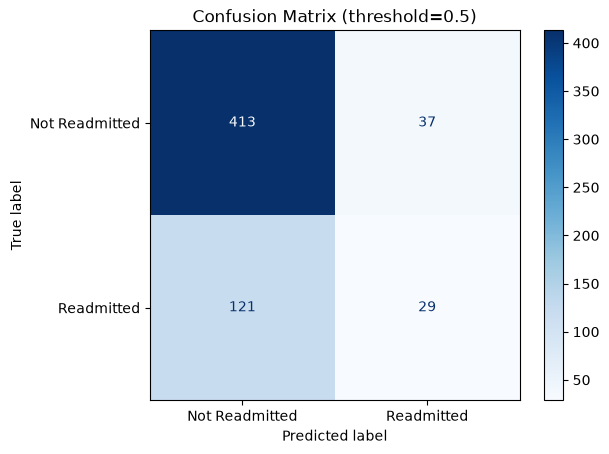

In [15]:
# Convert probabilities to class predictions using a threshold
threshold = 0.5  # start here, but you'll likely want to tune this later
y_pred = (y_pred_proba >= threshold).astype(int)

# Build the confusion matrix
cm = confusion_matrix(y_val, y_pred)
print(cm)

# Nicer visual version
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (threshold={threshold})')
plt.show()

TN (top-left): correctly predicted not readmitted
FP (top-right): predicted readmitted, but they weren't — a false alarm
FN (bottom-left): predicted not readmitted, but they were — a missed readmission (usually the costliest error clinically)
TP (bottom-right): correctly caught readmissions

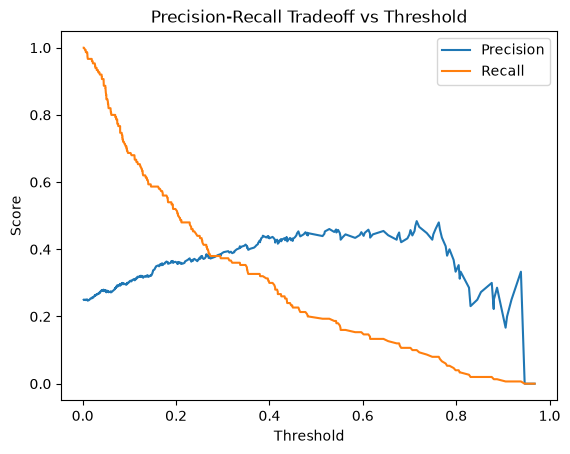

In [16]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_proba)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff vs Threshold')
plt.legend()
plt.show()

In [17]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)  # avoid div by zero
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print(f"Best threshold by F1: {best_threshold:.3f}")
print(f"Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}")


Best threshold by F1: 0.170
Precision: 0.358, Recall: 0.573


In [18]:
y.value_counts(normalize=True)

readmitted_30d
0    0.765333
1    0.234667
Name: proportion, dtype: float64

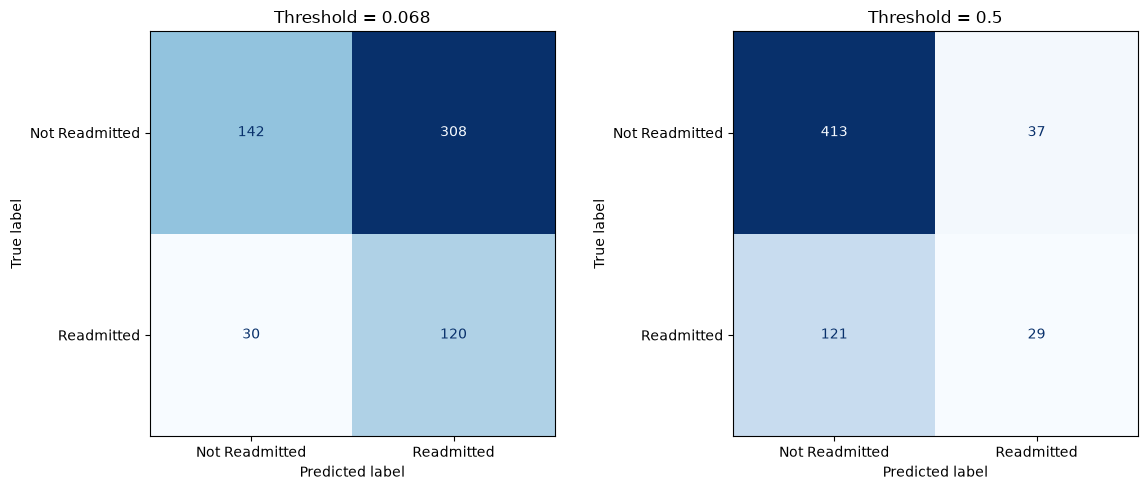

In [19]:
thresholds_to_compare = [0.068, 0.5]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, thresh in zip(axes, thresholds_to_compare):
    y_pred_temp = (y_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred_temp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Threshold = {thresh}')

plt.tight_layout()
plt.show()

At threshold 0.5, the model looks okay on paper (decent precision, high overall accuracy since it correctly predicts the majority "not readmitted" class most of the time) — but it's actually clinically almost useless, because it misses a large percent of the patients who actually get readmitted. This is a classic case of accuracy/precision looking fine while the metric that actually matters for the use case (catching real readmissions) is quietly terrible.
At 0.068, it flips that: it catches the vast majority of true readmissions, at the cost of a lot of false alarms — 208 patients get flagged unnecessarily.

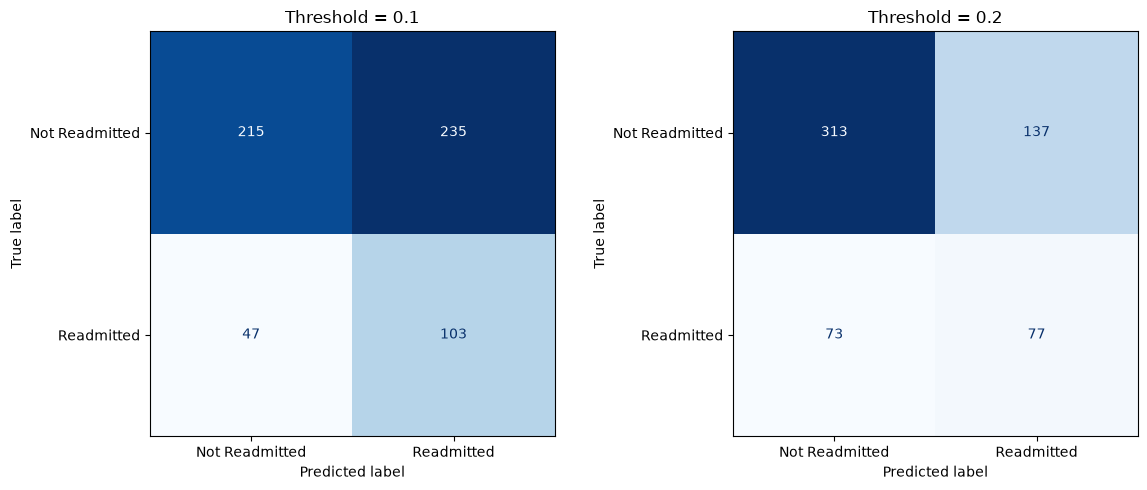

In [20]:
thresholds_to_compare = [0.1, 0.2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, thresh in zip(axes, thresholds_to_compare):
    y_pred_temp = (y_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred_temp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Threshold = {thresh}')

plt.tight_layout()
plt.show()

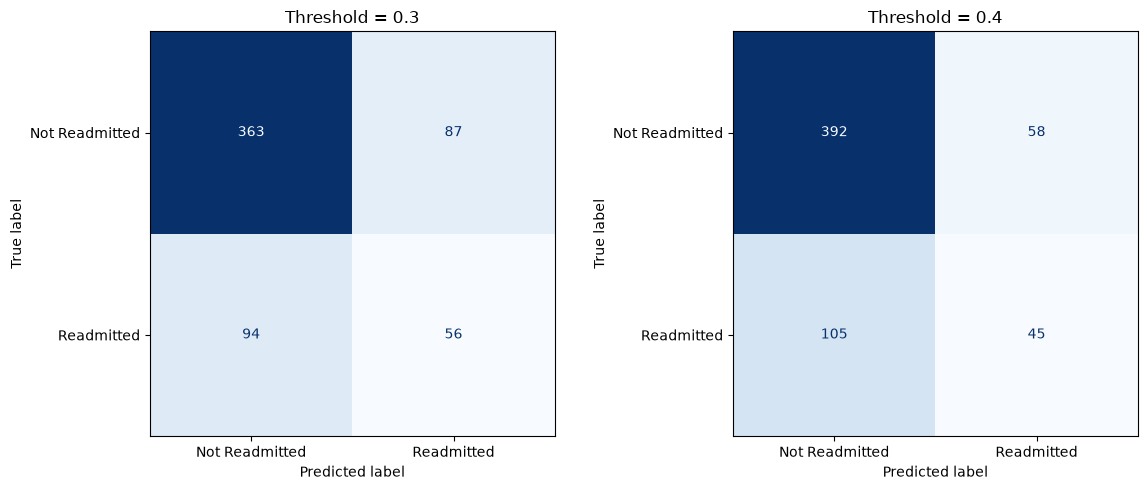

In [21]:
thresholds_to_compare = [0.3, 0.4]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, thresh in zip(axes, thresholds_to_compare):
    y_pred_temp = (y_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred_temp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Threshold = {thresh}')

plt.tight_layout()
plt.show()

Recall answers: "Out of everyone who really got readmitted, how many did we catch?"

Precision answers: "Out of everyone we warned about, how many warnings were correct?"

0.1 threshold: precision at 30.4% recall at 68.7%

0.2 threshold: precision at 35.9% recall at 51.3%

0.3 threshold: precision at 38.4% recall at 37.3%

0.4 threshold: precision at 43.7% recall at 30.0%

From the different thresholds above, we see the elbow at 0.2, that shows that the probable best threshold will be between 0.1 and 0.2. We are aiming for a higher recall, due to that being then the model successfully caught a readmission. 

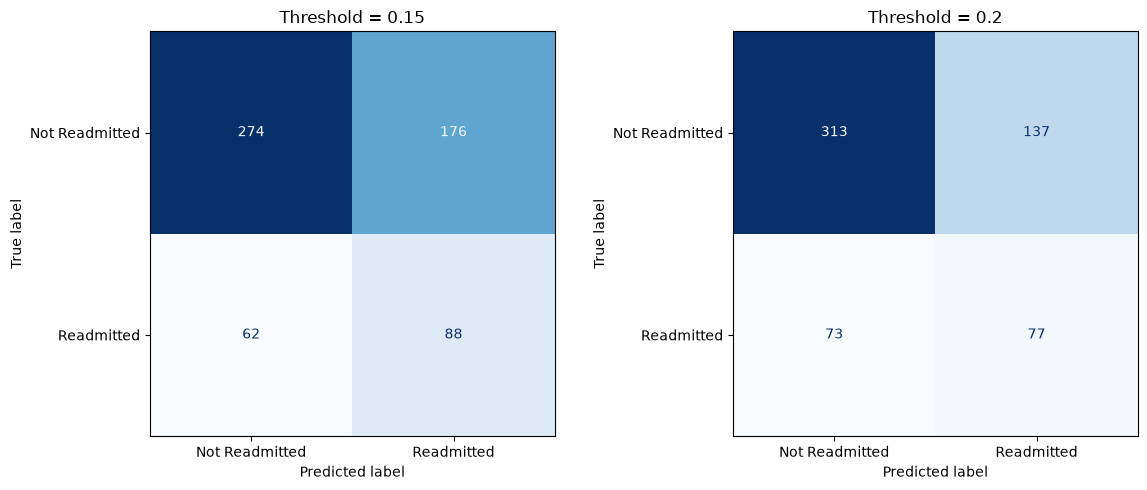

In [22]:
thresholds_to_compare = [0.15, 0.2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, thresh in zip(axes, thresholds_to_compare):
    y_pred_temp = (y_pred_proba >= thresh).astype(int)
    cm = confusion_matrix(y_val, y_pred_temp)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Threshold = {thresh}')

plt.tight_layout()
plt.show()

0.15 might actually be a nicer sweet spot than 0.2 — it gives meaningfully higher recall (58.6% vs 51.3%%) for only a small precision cost (33.3% vs 35.9%).

In [23]:
chosen_threshold = 0.15
y_pred_final = (y_pred_proba >= chosen_threshold).astype(int)

In [24]:
print(classification_report(y_val, y_pred_final, target_names=['Not Readmitted', 'Readmitted']))


                precision    recall  f1-score   support

Not Readmitted       0.82      0.61      0.70       450
    Readmitted       0.33      0.59      0.43       150

      accuracy                           0.60       600
     macro avg       0.57      0.60      0.56       600
  weighted avg       0.69      0.60      0.63       600



I selected a classification threshold of 0.15 rather than the default 0.5. At 0.15, the model catches 58% of true readmissions (vs. 17% at 0.5) while flagging a moderate 47% of patients for extra follow-up, at the cost of more false positives. Given that in a real clinical setting, a missed readmission is likely far more costly (extended illness, emergency readmission, downstream care costs) than an unnecessary follow-up call, prioritizing recall over precision is the more clinically sound choice.

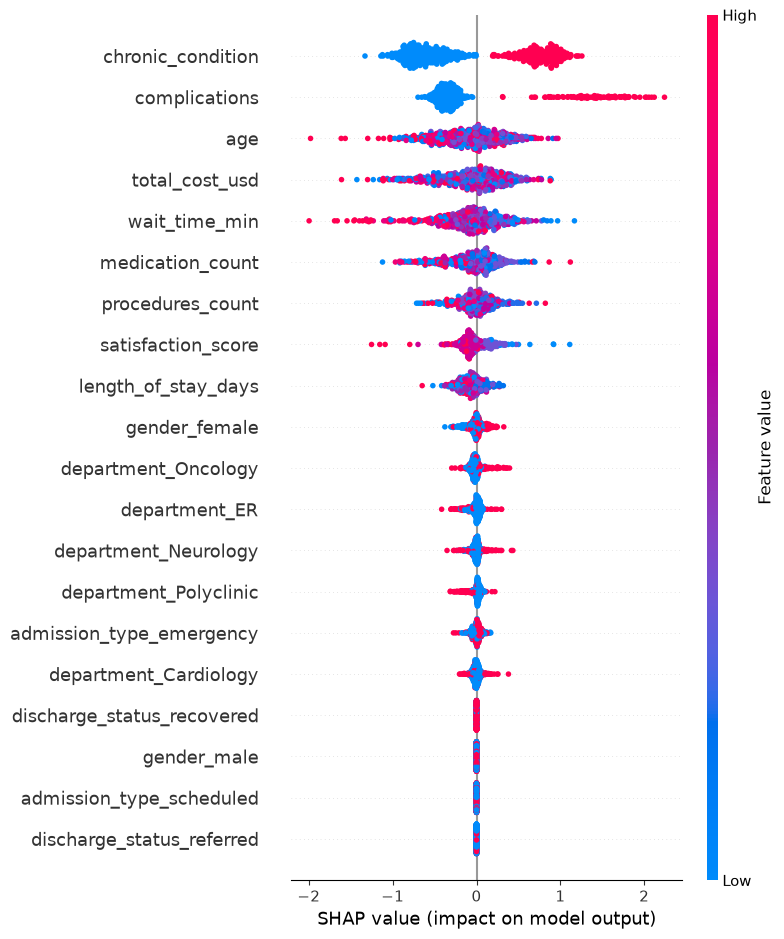

In [25]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_val)

shap.summary_plot(shap_values, x_val)

Above we have a graph created by the shap libray. 
The layout:

Y-axis: Your features, ordered from most important at the top to least important at the bottom. This ordering alone is valuable — it's telling you what the model actually relies on most.
X-axis: The SHAP value — essentially, "how much did this feature push the prediction toward readmission (positive/right) or away from it (negative/left) for this specific patient."
Each dot = one patient in your validation set. So a feature row is really hundreds of dots, one per patient, showing how that feature affected their individual prediction.
Color = the feature's actual value for that patient — typically red = high value, blue = low value (e.g., for age, red dots are older patients, blue dots are younger).

How to interpret a row:
Take a feature like medication_count. If you see:

Red dots (high medication count) clustered on the right (positive SHAP value) → more medications pushes predictions toward readmission.
Blue dots (low medication count) clustered on the left (negative SHAP value) → fewer medications pushes predictions away from readmission.

What does that tell us?
The plot actually shows us what makes perfect since. It tells us that a chronic condidion has a postive impact on the model, meaning it pushes twords readmission. Same with if the patient had any compliations. We can see if the patient has a low satisfaction score then they would be more likly to be readmitted, and if they had a shorter wait time they also were more likly to be readmitted. 

I would like to point out that benig a male has no little to no affect on if you are readmitted, but if you are female you are more likly to get readmitted. 

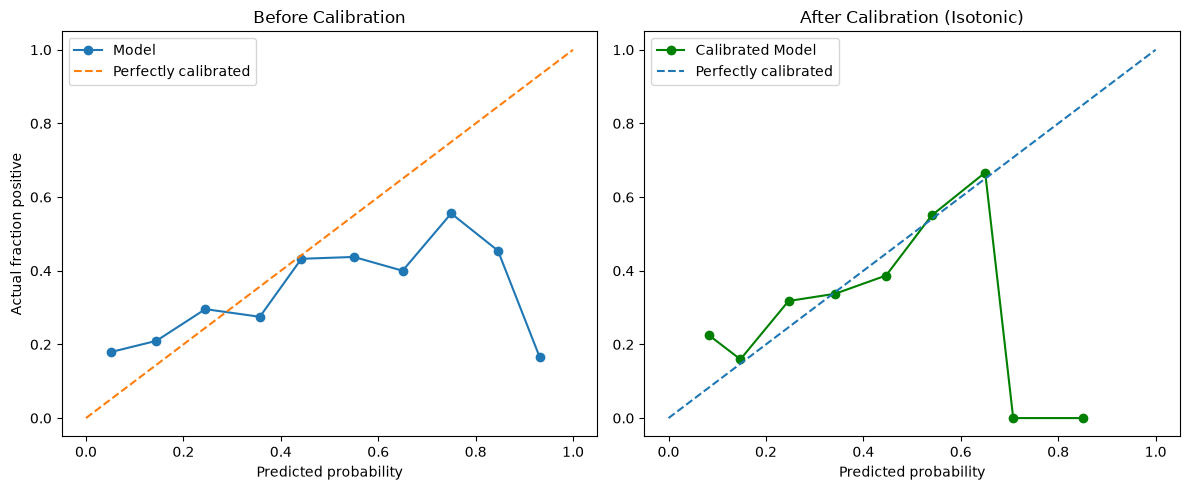

In [35]:
# Fit a calibrated version of your model
calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
calibrated_model.fit(x_train, y_train)

# Get calibrated probabilities
y_pred_proba_calibrated = calibrated_model.predict_proba(x_val)[:, 1]

# Plot both curves side by side for comparison
prob_true_orig, prob_pred_orig = calibration_curve(y_val, y_pred_proba, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_val, y_pred_proba_calibrated, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(prob_pred_orig, prob_true_orig, marker='o', label='Model')
axes[0].plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')
axes[0].set_title('Before Calibration')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Actual fraction positive')
axes[0].legend()

axes[1].plot(prob_pred_cal, prob_true_cal, marker='o', color='green', label='Calibrated Model')
axes[1].plot([0,1], [0,1], linestyle='--', label='Perfectly calibrated')
axes[1].set_title('After Calibration (Isotonic)')
axes[1].set_xlabel('Predicted probability')
axes[1].legend()

plt.tight_layout()
plt.show()

Before the model was calibrated, its probability outputs were well-ranked (as reflected in ROC AUC) but poorly calibrated above ~0.25 predicted probability, where the model is systematically overconfident. This means predicted probabilities should be used for relative risk ranking rather than as literal likelihoods without further calibration (e.g., isotonic regression).

After the model was calibrated, it is strong and reliable across the bulk of the prediction range (0.0–0.6), which covers the vast majority of patients. Above 0.6, calibration estimates become unstable due to very few validation samples receiving such high predicted probabilities (fewer than 10 patients total above 0.6). This is a data limitation rather than a modeling flaw — a larger validation set would be needed to properly evaluate calibration at the highest-risk end.

In [30]:
print("Calibrated ROC AUC:", roc_auc_score(y_val, y_pred_proba_calibrated))
print("Calibrated PR AUC:", average_precision_score(y_val, y_pred_proba_calibrated))

Calibrated ROC AUC: 0.6402148148148149
Calibrated PR AUC: 0.3741766378349058


As expected, isotonic calibration had minimal effect on ROC AUC (0.631 → 0.640) and PR AUC (0.356 → 0.374), since isotonic regression preserves rank order and these metrics are rank-based. The meaningful improvement from calibration is reflected in the calibration curve itself, not in ranking metrics — the model's predicted probabilities became substantially more trustworthy as literal likelihood estimates, which matters for clinical interpretability even though it doesn't change how well the model discriminates between classes.

In [38]:
roc_scores = cross_val_score(model, x_encoded, y, cv=5, scoring='roc_auc')
pr_scores = cross_val_score(model, x_encoded, y, cv=5, scoring='average_precision')

print(f"ROC AUC: {roc_scores.mean():.3f} ± {roc_scores.std():.3f}")
print(f"PR AUC: {pr_scores.mean():.3f} ± {pr_scores.std():.3f}")

ROC AUC: 0.678 ± 0.021
PR AUC: 0.409 ± 0.024


In [39]:
baseline = LogisticRegression(max_iter=1000)
baseline.fit(x_train, y_train)
baseline_proba = baseline.predict_proba(x_val)[:, 1]

print("Baseline ROC AUC:", roc_auc_score(y_val, baseline_proba))
print("Baseline PR AUC:", average_precision_score(y_val, baseline_proba))


Baseline ROC AUC: 0.7237481481481483
Baseline PR AUC: 0.44985617440229964


/opt/anaconda3/envs/readmission/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic regression baseline beats XGBoost on both metrics.
This suggests the real relationships in the (synthetic) data are mostly linear/simple, which logistic regression captures natively, while XGBoost's extra complexity (handling non-linear interactions) isn't helping anything here — it might even be overfitting slightly to noise that doesn't generalize.

In [40]:
# fairness check for gender
# Split validation set by gender
# (using x_val before encoding collapsed gender, so pull the mask from your original val indices)
male_mask = x_val['gender_male'] == True   # adjust column name to match your actual encoding
female_mask = x_val['gender_female'] == True

# Compute ROC AUC separately for each group
male_auc = roc_auc_score(y_val[male_mask], y_pred_proba[male_mask])
female_auc = roc_auc_score(y_val[female_mask], y_pred_proba[female_mask])

print(f"Male ROC AUC: {male_auc:.3f} (n={male_mask.sum()})")
print(f"Female ROC AUC: {female_mask.sum()}")
print(f"Female ROC AUC: {female_auc:.3f} (n={female_mask.sum()})")

Male ROC AUC: 0.670 (n=295)
Female ROC AUC: 305
Female ROC AUC: 0.594 (n=305)


The model shows a fairness gap, performing meaningfully better for male patients (AUC 0.670) than female patients (AUC 0.594). Since this is synthetic data, the cause is unclear — it may reflect how the data was generated rather than a real clinical pattern — but this would need investigation before any real-world deployment.